<a href="https://colab.research.google.com/github/carpotru08-cmd/Introducci-n_Ciencia_Datos_UdeM/blob/main/Trabajo%20Final/EDA_Ventas_Rentabilidad_Ciencia_Datos_UdeM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos — Ventas y Rentabilidad 2022–2025

Este notebook desarrolla un **Análisis Exploratorio de Datos (EDA)** sobre un conjunto de transacciones comerciales entre 2022 y 2025.


## Pregunta principal del análisis

Nuestro objetivo es entender:

> **¿Qué características de las ventas, productos, clientes, canales y periodos están asociadas con una mayor rentabilidad?**

Para responderla utilizaremos tres indicadores complementarios:

| Indicador | Qué representa | Pregunta que responde |
|---|---|---|
| `Sales_Amount` | Dinero generado por las ventas | ¿Dónde vendemos más? |
| `Profit` | Utilidad reportada en el dataset | ¿Dónde ganamos más dinero? |
| `Profit_Margin` | `Profit` como porcentaje de las ventas | ¿Dónde convertimos mejor las ventas en ganancia? |

Esto es importante porque **vender más no necesariamente significa ser más rentable**.

---

## Estructura del notebook

### Etapa 1 — Análisis inicial
Conocer la estructura, tipos de variables, valores faltantes, duplicados e inconsistencias.

### Etapa 2 — Limpieza
Corregir o tratar los problemas encontrados y documentar por qué se toma cada decisión.

### Etapa 3 — Creación y selección de variables
Crear variables útiles, revisar correlaciones y definir qué variables aportan información distinta.

### Etapa 4 — Análisis exploratorio
Estudiar ventas, utilidad y margen desde diferentes dimensiones: producto, canal, tiempo, descuentos, clientes y países.

---

## Equivalencia con SQL

En cinco análisis seleccionados también construiremos la consulta equivalente en **SQL ejecutada desde Python**.  
La intención no es repetir todo el EDA en dos lenguajes, sino practicar cómo una misma pregunta de negocio puede resolverse con Pandas o con SQL.

Se escogieron casos con dificultad progresiva: desde un `GROUP BY` básico hasta consultas con `CASE WHEN`, CTE y agregaciones condicionales.

# 1. Análisis inicial de los datos

Antes de modificar cualquier dato debemos entender **qué contiene el archivo y cuál es la calidad de la información**.

En esta etapa todavía no corregimos nada. Primero observamos.

## 1.1 Carga del archivo y primera vista

Importamos las librerías que utilizaremos:

- **Pandas:** manipulación de tablas.
- **NumPy:** operaciones numéricas.
- **Matplotlib y Seaborn:** gráficos estadísticos.

Después cargamos el archivo CSV en un objeto llamado `df`.  
Un **DataFrame** es simplemente una tabla de datos dentro de Python.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter

# Estilo básico para los gráficos de Matplotlib/Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Cargar el archivo
df = pd.read_csv("/content/Sales_transactions_2022_2025.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head())


Dimensiones del dataset: (18045, 36)


,Transaction_ID,Order_ID,Customer_ID,Customer_Name,Customer_Age,Customer_Gender,Customer_Segment,Order_Date,Order_Time,Sales_Channel,...,Order_Status,Shipping_Method,Delivery_Days,Return_Flag,Return_Reason,Sales_Representative,Promotion_Code,Customer_Rating,Inventory_Level,Order_Year
0,T02016694,O0116694,C01482,Sophia Smith,28.0,Male,Consumer,2022-10-06,11:30:55,Online,...,Completed,Standard,4.0,No,NaN,James Anderson,SAVE10,4.0,81.0,2022
1,T02016374,O0108187,C01591,Hannah King,46.0,Female,Consumer,2024-06-03,17:06:29,Online,...,Completed,Standard,6.0,No,NaN,Ella Lewis,NaN,5.0,123.0,2024
2,T02004099,O0104099,C04140,Emma Wilson,42.0,Male,Consumer,2024-12-19,08:22:11,Online,...,Shipped,Standard,4.0,No,NaN,Liam Davis,NaN,4.0,93.0,2024
3,T02010280,O0110280,C03663,Daniel Clark,18.0,Male,Corporate,2025-10-05,14:32:43,B2B Portal,...,Completed,Next Day,2.0,No,NaN,Grace Harris,HOLIDAY20,NaN,59.0,2025
4,T02012685,O0112685,C02749,Sophia Smith,37.0,Male,Returning Customer,2022-09-13,14:55:16,B2B Portal,...,Completed,Express,2.0,No,NaN,Sophia Brown,NaN,2.0,56.0,2022


### ¿Cómo interpretamos `shape`?

`df.shape` devuelve dos números:

- el primero corresponde a la cantidad de **filas**;
- el segundo corresponde a la cantidad de **columnas**.

En este archivo encontramos **18.045 registros y 36 variables** antes de realizar la limpieza.

## 1.2 ¿Qué representa una fila?

Antes de analizar cualquier dataset debemos conocer su **nivel de detalle**.

Vamos a revisar cuántos valores únicos existen en los principales identificadores:

- `Transaction_ID`: identificador de la transacción.
- `Order_ID`: identificador del pedido.
- `Customer_ID`: identificador del cliente.
- `Product_ID`: identificador del producto.

Si un pedido aparece varias veces, no significa necesariamente que sea un duplicado: puede contener varios productos.

In [ ]:
print("Valores únicos en identificadores principales:")

display(
    df[
        ["Transaction_ID", "Order_ID", "Customer_ID", "Product_ID"]
    ].nunique()
)

print("\nPedidos que aparecen más veces:")
display(df["Order_ID"].value_counts().head(10))

Valores únicos en identificadores principales:


,0
Transaction_ID,18000
Order_ID,14541
Customer_ID,4882
Product_ID,28



Pedidos que aparecen más veces:


,count
Order_ID,
O0101601,4
O0103093,4
O0104930,4
O0102892,4
O0104225,3
O0100735,3
O0106867,3
O0104653,3
O0104045,3


### Interpretación

El número de `Order_ID` es menor que el número de filas.  
Esto indica que **un mismo pedido puede ocupar varias filas**, por ejemplo porque contiene más de un producto.

Por lo tanto:

> **No debemos eliminar registros solamente porque el `Order_ID` esté repetido.**

El identificador que esperamos que sea único por registro es `Transaction_ID`.

## 1.3 Tipos de variables

Las variables pueden representar diferentes tipos de información.

### Variables numéricas
Representan cantidades sobre las que tiene sentido realizar operaciones matemáticas.

Ejemplos:
- edad;
- cantidad;
- precio;
- ventas;
- costos;
- utilidad.

### Variables categóricas
Representan grupos o clases.

Ejemplos:
- género;
- país;
- categoría de producto;
- canal de venta.

### Variables temporales
Representan fechas o tiempo.

Ejemplo:
- `Order_Date`.

Usamos `info()` para observar cómo interpretó Pandas cada columna.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18045 entries, 0 to 18044
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        18045 non-null  object 
 1   Order_ID              18045 non-null  object 
 2   Customer_ID           18045 non-null  object 
 3   Customer_Name         17937 non-null  object 
 4   Customer_Age          17827 non-null  float64
 5   Customer_Gender       17883 non-null  object 
 6   Customer_Segment      18045 non-null  object 
 7   Order_Date            18045 non-null  object 
 8   Order_Time            18045 non-null  object 
 9   Sales_Channel         18045 non-null  object 
 10  Store_ID              18045 non-null  object 
 11  Store_Name            18045 non-null  object 
 12  Country               18045 non-null  object 
 13  Region                18045 non-null  object 
 14  City                  18045 non-null  object 
 15  Product_ID         

La columna `Order_Date` llega inicialmente como texto (`object`).  
Para analizar meses, años o trimestres necesitamos convertirla a fecha.

In [ ]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

print(df[["Order_Date", "Order_Time", "Order_Year"]].dtypes)

Order_Date    datetime64[ns]
Order_Time            object
Order_Year             int64
dtype: object


## 1.4 Clasificación de variables

Creamos listas con las variables numéricas y categóricas principales.  
Estas listas nos ayudarán a organizar los análisis posteriores.

In [ ]:
variables_numericas = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percentage",
    "Sales_Amount",
    "Cost_Amount",
    "Profit",
    "Delivery_Days",
    "Customer_Rating",
    "Inventory_Level"
]

variables_categoricas = [
    "Customer_Gender",
    "Customer_Segment",
    "Sales_Channel",
    "Country",
    "Region",
    "City",
    "Product_Name",
    "Product_Category",
    "Product_Subcategory",
    "Payment_Method",
    "Order_Status",
    "Shipping_Method",
    "Return_Flag",
    "Return_Reason",
    "Promotion_Code"
]

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Percentage', 'Sales_Amount', 'Cost_Amount', 'Profit', 'Delivery_Days', 'Customer_Rating', 'Inventory_Level']

Variables categóricas:
['Customer_Gender', 'Customer_Segment', 'Sales_Channel', 'Country', 'Region', 'City', 'Product_Name', 'Product_Category', 'Product_Subcategory', 'Payment_Method', 'Order_Status', 'Shipping_Method', 'Return_Flag', 'Return_Reason', 'Promotion_Code']


## 1.5 Valores faltantes y duplicados

Un **valor faltante** aparece cuando una celda no contiene información.

Pero un valor faltante **no siempre significa un error**.

Por ejemplo:

- si una venta no fue devuelta, es normal que `Return_Reason` esté vacío;
- si no se utilizó una promoción, `Promotion_Code` puede estar vacío;
- si el cliente no calificó su compra, `Customer_Rating` puede estar vacío.

También revisaremos si existen filas completamente repetidas.

In [ ]:
nulos = df.isna().sum()

porcentaje_nulos = (
    df.isna().mean() * 100
).round(2)

tabla_nulos = pd.DataFrame({
    "Cantidad": nulos,
    "Porcentaje": porcentaje_nulos
})

tabla_nulos = tabla_nulos[
    tabla_nulos["Cantidad"] > 0
].sort_values("Porcentaje", ascending=False)

display(tabla_nulos)

print("Filas completamente duplicadas:", df.duplicated().sum())
print(
    "Transaction_ID duplicados:",
    df["Transaction_ID"].duplicated().sum()
)

,Cantidad,Porcentaje
Return_Reason,16168,89.60
Promotion_Code,9737,53.96
Customer_Rating,3435,19.04
Customer_Age,218,1.21
Inventory_Level,198,1.10
Delivery_Days,162,0.90
Customer_Gender,162,0.90
Payment_Method,147,0.81
Product_Name,144,0.80
Customer_Name,108,0.60


Filas completamente duplicadas: 45
Transaction_ID duplicados: 45


### Interpretación

Los valores faltantes se tratarán según su significado, no con una única regla para todas las columnas.

También encontramos filas completamente duplicadas.  
Estas sí pueden eliminarse porque representan exactamente la misma información repetida.

## 1.6 Estadística descriptiva

`describe()` resume las variables numéricas.

Entre otros valores muestra:

- mínimo;
- promedio;
- mediana;
- máximo;
- cuartiles.

Esto permite detectar rápidamente valores que parecen imposibles o poco razonables.

In [ ]:
display(
    df[variables_numericas]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Customer_Age,17827.0,38.916924,10.727357,4.00,32.00,39.00,46.00,112.00
Quantity,18045.0,2.127127,1.786212,-3.00,1.00,2.00,3.00,11.00
Unit_Price,18045.0,232.685633,294.208022,21.39,53.38,99.87,285.58,1425.09
Discount_Percentage,18045.0,6.256858,6.881178,0.00,0.00,5.00,10.00,110.00
Sales_Amount,18045.0,457.309027,856.597181,16.68,78.53,168.81,472.45,14303.07
Cost_Amount,18045.0,366.001156,705.866738,12.17,56.12,122.30,376.02,10791.00
Profit,18045.0,91.404131,167.827883,-299.31,19.48,40.19,93.27,3512.08
Delivery_Days,17883.0,2.262204,2.321656,0.00,0.00,1.00,4.00,10.00
Customer_Rating,14610.0,3.985969,1.008422,1.00,4.00,4.00,5.00,5.00
Inventory_Level,17847.0,70.257914,22.042609,0.00,55.00,70.00,85.00,157.00


## 1.7 Revisión de categorías

Dos textos diferentes pueden representar realmente la misma categoría.

Por ejemplo:

- `Male` y `male`;
- `Electronics` y `electronics`;
- `PayPal` y `paypal`.

Si no los unificamos, Python los tratará como grupos distintos.

In [ ]:
columnas_revisar = [
    "Customer_Gender",
    "Product_Category",
    "Payment_Method",
    "Order_Status",
    "City"
]

for columna in columnas_revisar:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(dropna=False))


--- Customer_Gender ---
Customer_Gender
Female        8742
Male          8438
Non-binary     543
NaN            162
male            77
FEMALE          75
Non Binary       8
Name: count, dtype: int64

--- Product_Category ---
Product_Category
Electronics        8142
Office Supplies    4506
Furniture          3279
Appliances         1988
electronics          67
FURNITURE            32
Office supplies      31
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
Credit Card      6741
Debit Card       3899
PayPal           2800
Bank Transfer    2138
Apple Pay        1088
Cash             1042
NaN               147
credit card        79
DebitCard          66
paypal             23
Bank transfer      22
Name: count, dtype: int64

--- Order_Status ---
Order_Status
Completed     11462
Shipped        2547
Returned       1601
Processing     1415
Cancelled       898
completed       100
SHIPPED          14
processing        8
Name: count, dtype: int64

--- City ---
City
New York       2

## 1.8 Valores numéricos sospechosos

Buscamos reglas básicas que deberían cumplirse:

- una edad no debería ser negativa o excesivamente alta;
- una cantidad vendida debería ser positiva;
- un descuento no debería superar 100%;
- una utilidad negativa puede existir y **no necesariamente es un error**.

In [ ]:
print("Edades menores de 18:", (df["Customer_Age"] < 18).sum())
print("Edades mayores de 100:", (df["Customer_Age"] > 100).sum())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print(
    "Descuentos fuera de 0-100%:",
    (~df["Discount_Percentage"].between(0, 100)).sum()
)
print("Profit negativo:", (df["Profit"] < 0).sum())

Edades menores de 18: 2
Edades mayores de 100: 1
Quantity <= 0: 8
Descuentos fuera de 0-100%: 1
Profit negativo: 232


## 1.9 Validación de la utilidad (`Profit`)

La utilidad monetaria debería ser aproximadamente:

> **Ventas − Costos**

Por eso verificamos si:

`Profit ≈ Sales_Amount - Cost_Amount`

Permitimos una diferencia pequeña de hasta **$0,02** por efectos de redondeo.

In [ ]:
profit_calculado = (
    df["Sales_Amount"] - df["Cost_Amount"]
)

diferencia_profit = (
    profit_calculado - df["Profit"]
).abs()

print(
    "Registros con diferencia mayor a $0.02:",
    (diferencia_profit > 0.02).sum()
)

print(
    "Porcentaje:",
    round((diferencia_profit > 0.02).mean() * 100, 2),
    "%"
)

print(
    "Mayor diferencia encontrada: $",
    round(diferencia_profit.max(), 2)
)

Registros con diferencia mayor a $0.02: 110
Porcentaje: 0.61 %
Mayor diferencia encontrada: $ 321.57


### ¿Qué decisión tomamos?

La gran mayoría de los registros presenta una relación coherente entre ventas, costos y `Profit`, aunque existe un grupo pequeño con diferencias superiores al margen de redondeo.

Para este ejercicio tomamos una decisión sencilla:

> **Trabajaremos con la columna `Profit` original del dataset como la variable oficial de utilidad.**

No crearemos una segunda variable de utilidad.

La validación anterior se conserva porque es importante documentar que encontramos una pequeña inconsistencia de calidad en algunos registros. Esto debe tenerse en cuenta al interpretar los resultados, pero no cambiaremos los valores originales de `Profit`.


# 2. Limpieza de datos

Ahora sí corregiremos los problemas encontrados.

Primero creamos una copia llamada `df_clean`.

Esto permite conservar `df` como versión original y tener una segunda tabla sobre la cual realizar cambios.

In [ ]:
df_clean = df.copy()

print("Filas antes de limpiar:", len(df_clean))

# Eliminar filas completamente duplicadas
df_clean = df_clean.drop_duplicates()

print("Filas después de eliminar duplicados:", len(df_clean))

Filas antes de limpiar: 18045
Filas después de eliminar duplicados: 18000


## 2.1 Estandarización de texto

Primero eliminamos espacios al inicio o final de las cadenas.

Después unificamos valores que significan lo mismo pero fueron escritos de manera diferente.

In [ ]:
columnas_texto = df_clean.select_dtypes(
    include="object"
).columns

for columna in columnas_texto:
    df_clean[columna] = (
        df_clean[columna]
        .str.strip()
    )

df_clean["Customer_Gender"] = df_clean["Customer_Gender"].replace({
    "male": "Male",
    "FEMALE": "Female",
    "Non Binary": "Non-binary"
})

df_clean["Product_Category"] = df_clean["Product_Category"].replace({
    "electronics": "Electronics",
    "FURNITURE": "Furniture",
    "Office supplies": "Office Supplies"
})

df_clean["Payment_Method"] = df_clean["Payment_Method"].replace({
    "credit card": "Credit Card",
    "DebitCard": "Debit Card",
    "paypal": "PayPal",
    "Bank transfer": "Bank Transfer"
})

df_clean["City"] = df_clean["City"].replace({
    "LOS ANGELES": "Los Angeles",
    "munich": "Munich"
})

df_clean["Region"] = df_clean["Region"].replace({
    "North East": "Northeast",
    "British columbia": "British Columbia",
    "NRW": "North Rhine-Westphalia"
})

df_clean["Order_Status"] = df_clean["Order_Status"].replace({
    "completed": "Completed",
    "SHIPPED": "Shipped",
    "processing": "Processing"
})

## 2.2 Tratamiento de valores faltantes

No todos los nulos se tratan de la misma forma.

Usaremos reglas sencillas:

| Variable | Acción | Razón |
|---|---|---|
| `Customer_Age` | promedio | pocos faltantes y es numérica |
| `Customer_Gender` | moda | es categórica |
| `Inventory_Level` | promedio | variable numérica |
| `Delivery_Days` | mediana | reduce el efecto de valores extremos |
| `Payment_Method` | `"Unknown"` | no podemos inventar el método |
| nombres | `"Unknown"` | no podemos reconstruirlos con certeza |
| `Promotion_Code` | `"No Promotion"` | ausencia significa que no hay código registrado |
| `Return_Reason` | `"Not Applicable"` | si no hay devolución, la razón no aplica |
| `Customer_Rating` | se conserva nulo | inventar una calificación alteraría la opinión del cliente |

In [ ]:
# Edades imposibles se convierten temporalmente en NaN
df_clean.loc[
    (df_clean["Customer_Age"] < 18) |
    (df_clean["Customer_Age"] > 100),
    "Customer_Age"
] = np.nan

# Edad por promedio
promedio_edad = round(
    df_clean["Customer_Age"].mean()
)

df_clean["Customer_Age"] = (
    df_clean["Customer_Age"]
    .fillna(promedio_edad)
)

# Género por moda
moda_genero = (
    df_clean["Customer_Gender"]
    .mode()[0]
)

df_clean["Customer_Gender"] = (
    df_clean["Customer_Gender"]
    .fillna(moda_genero)
)

# Inventario por promedio
promedio_inventario = round(
    df_clean["Inventory_Level"].mean()
)

df_clean["Inventory_Level"] = (
    df_clean["Inventory_Level"]
    .fillna(promedio_inventario)
)

# Días de entrega por mediana
mediana_delivery = round(
    df_clean["Delivery_Days"].median()
)

df_clean["Delivery_Days"] = (
    df_clean["Delivery_Days"]
    .fillna(mediana_delivery)
)

# Categóricas
df_clean["Payment_Method"] = (
    df_clean["Payment_Method"]
    .fillna("Unknown")
)

df_clean["Customer_Name"] = (
    df_clean["Customer_Name"]
    .fillna("Unknown")
)

df_clean["Product_Name"] = (
    df_clean["Product_Name"]
    .fillna("Unknown")
)

df_clean["Promotion_Code"] = (
    df_clean["Promotion_Code"]
    .fillna("No Promotion")
)

df_clean["Return_Reason"] = (
    df_clean["Return_Reason"]
    .fillna("Not Applicable")
)

print("Promedio de edad usado:", promedio_edad)
print("Promedio de inventario usado:", promedio_inventario)
print("Mediana de días de entrega:", mediana_delivery)
print("Moda de género:", moda_genero)

Promedio de edad usado: 39
Promedio de inventario usado: 70
Mediana de días de entrega: 1
Moda de género: Female


## 2.3 Valores numéricos inválidos

Encontramos algunas cantidades iguales o menores a cero y un descuento fuera del rango posible.

Como queremos mantener métodos básicos:

- cantidades inválidas → mediana de las cantidades válidas;
- descuentos fuera de 0–100% → mediana de los descuentos válidos.

Estas filas son muy pocas, por lo que la decisión tiene un impacto mínimo en el análisis general.

In [ ]:
mediana_cantidad = round(
    df_clean.loc[
        df_clean["Quantity"] > 0,
        "Quantity"
    ].median()
)

df_clean.loc[
    df_clean["Quantity"] <= 0,
    "Quantity"
] = mediana_cantidad

mediana_descuento = (
    df_clean.loc[
        df_clean["Discount_Percentage"]
        .between(0, 100),
        "Discount_Percentage"
    ]
    .median()
)

df_clean.loc[
    ~df_clean["Discount_Percentage"]
    .between(0, 100),
    "Discount_Percentage"
] = mediana_descuento

print("Mediana de Quantity:", mediana_cantidad)
print("Mediana de descuento:", mediana_descuento)

Mediana de Quantity: 2
Mediana de descuento: 5.0


## 2.4 Conversión de tipos

Algunas columnas representan cantidades enteras y otras representan categorías.

Convertirlas al tipo adecuado ayuda a que Python entienda mejor su significado.

In [ ]:
df_clean["Customer_Age"] = (
    df_clean["Customer_Age"].astype(int)
)

df_clean["Delivery_Days"] = (
    df_clean["Delivery_Days"].astype(int)
)

df_clean["Inventory_Level"] = (
    df_clean["Inventory_Level"].astype(int)
)

categorias_convertir = [
    "Customer_Gender",
    "Customer_Segment",
    "Sales_Channel",
    "Product_Category",
    "Payment_Method",
    "Order_Status",
    "Shipping_Method",
    "Return_Flag"
]

for columna in categorias_convertir:
    df_clean[columna] = (
        df_clean[columna]
        .astype("category")
    )

display(df_clean[categorias_convertir].dtypes)

,0
Customer_Gender,category
Customer_Segment,category
Sales_Channel,category
Product_Category,category
Payment_Method,category
Order_Status,category
Shipping_Method,category
Return_Flag,category


## 2.5 Dataset auxiliar para calificaciones

`Customer_Rating` conserva sus valores faltantes.

Si queremos analizar esta variable utilizaremos únicamente los registros donde sí existe una calificación.

In [ ]:
df_rating = (
    df_clean
    .dropna(subset=["Customer_Rating"])
    .copy()
)

print("Dataset completo:", df_clean.shape)
print("Dataset con rating:", df_rating.shape)

Dataset completo: (18000, 36)
Dataset con rating: (14570, 36)


## 2.6 Validación final de la limpieza

Al terminar comprobamos que:

- no existan filas completamente duplicadas;
- las cantidades sean positivas;
- los descuentos estén entre 0 y 100;
- los nulos restantes sean conocidos y deliberados.

In [ ]:
print(
    "Duplicados restantes:",
    df_clean.duplicated().sum()
)

print(
    "Quantity <= 0:",
    (df_clean["Quantity"] <= 0).sum()
)

print(
    "Descuentos fuera de 0-100%:",
    (
        ~df_clean["Discount_Percentage"]
        .between(0, 100)
    ).sum()
)

print("\nNulos restantes:")
print(
    df_clean.isna().sum()[
        df_clean.isna().sum() > 0
    ]
)

Duplicados restantes: 0
Quantity <= 0: 0
Descuentos fuera de 0-100%: 0

Nulos restantes:
Customer_Rating    3430
dtype: int64


# 3. Creación y selección de variables

Los datos originales no siempre contienen exactamente las variables que queremos analizar.

En esta etapa creamos nuevas variables a partir de las existentes.

La idea no es inventar información: cada nueva variable debe tener una fórmula o lógica clara.

## 3.1 Nuevas variables

A partir de las columnas existentes crearemos variables que facilitan el análisis:

| Variable | Cálculo | Utilidad |
|---|---|---|
| `Profit_Margin` | `Profit / Sales_Amount × 100` | eficiencia de la venta |
| `Gross_Sales` | Cantidad × Precio | valor estimado antes del descuento |
| `Discount_Amount` | Venta bruta − Venta final | dinero cedido en descuento |
| `Has_Promotion` | 1/0 | identifica si hubo código promocional |
| `Order_Month` | mes | análisis temporal |
| `Order_Quarter` | trimestre | análisis temporal |
| `Year_Quarter` | año + trimestre | evolución sin mezclar años |
| `Day_of_Week` | día | comportamiento semanal |
| `Age_Group` | rangos de edad | facilitar comparación de clientes |
| `Is_Returned` | 1/0 | facilitar análisis de devoluciones |

`Profit` **no es una variable nueva**: utilizaremos directamente la columna que ya existe en el dataset.


In [ ]:
df_eda = df_clean.copy()

# 2. Margen porcentual
df_eda["Profit_Margin"] = (
    df_eda["Profit"]
    / df_eda["Sales_Amount"]
    * 100
)

# 3. Venta bruta
df_eda["Gross_Sales"] = (
    df_eda["Quantity"]
    * df_eda["Unit_Price"]
)

# 4. Dinero descontado
df_eda["Discount_Amount"] = (
    df_eda["Gross_Sales"]
    - df_eda["Sales_Amount"]
)

# 5. Uso de promoción
df_eda["Has_Promotion"] = (
    df_eda["Promotion_Code"]
    != "No Promotion"
).astype(int)

# 6. Variables de fecha
df_eda["Order_Year"] = (
    df_eda["Order_Date"].dt.year
)

df_eda["Order_Month"] = (
    df_eda["Order_Date"].dt.month
)

df_eda["Order_Quarter"] = (
    df_eda["Order_Date"].dt.quarter
)

df_eda["Year_Quarter"] = (
    df_eda["Order_Year"].astype(str)
    + "-Q"
    + df_eda["Order_Quarter"].astype(str)
)

df_eda["Day_of_Week"] = (
    df_eda["Order_Date"].dt.day_name()
)

# 7. Rangos de edad
df_eda["Age_Group"] = pd.cut(
    df_eda["Customer_Age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)

# 8. Devolución binaria
df_eda["Is_Returned"] = (
    df_eda["Return_Flag"]
    == "Yes"
).astype(int)

display(
    df_eda[[
        "Sales_Amount",
        "Profit",
        "Profit_Margin",
        "Gross_Sales",
        "Discount_Amount",
        "Has_Promotion",
        "Year_Quarter",
        "Age_Group"
    ]].head()
)

,Sales_Amount,Profit,Profit_Margin,Gross_Sales,Discount_Amount,Has_Promotion,Year_Quarter,Age_Group
0,162.05,46.44,28.657822,170.58,8.53,1,2022-Q4,26-35
1,300.13,63.13,21.034219,353.10,52.97,0,2024-Q2,46-55
2,74.66,1.49,1.995714,87.84,13.18,0,2024-Q4,36-45
3,1078.46,180.55,16.741465,1268.74,190.28,1,2025-Q4,18-25
4,237.03,72.08,30.409653,278.84,41.81,0,2022-Q3,36-45


## 3.2 Correlación: ¿qué significa?

La **correlación** mide qué tan relacionadas están dos variables numéricas de forma lineal.

Su valor va de **−1 a 1**:

- cerca de **1** → cuando una aumenta, la otra también suele aumentar;
- cerca de **−1** → cuando una aumenta, la otra suele disminuir;
- cerca de **0** → no existe una relación lineal clara.

> Correlación **no significa causalidad**.

También utilizamos la correlación para detectar variables que prácticamente contienen la misma información.

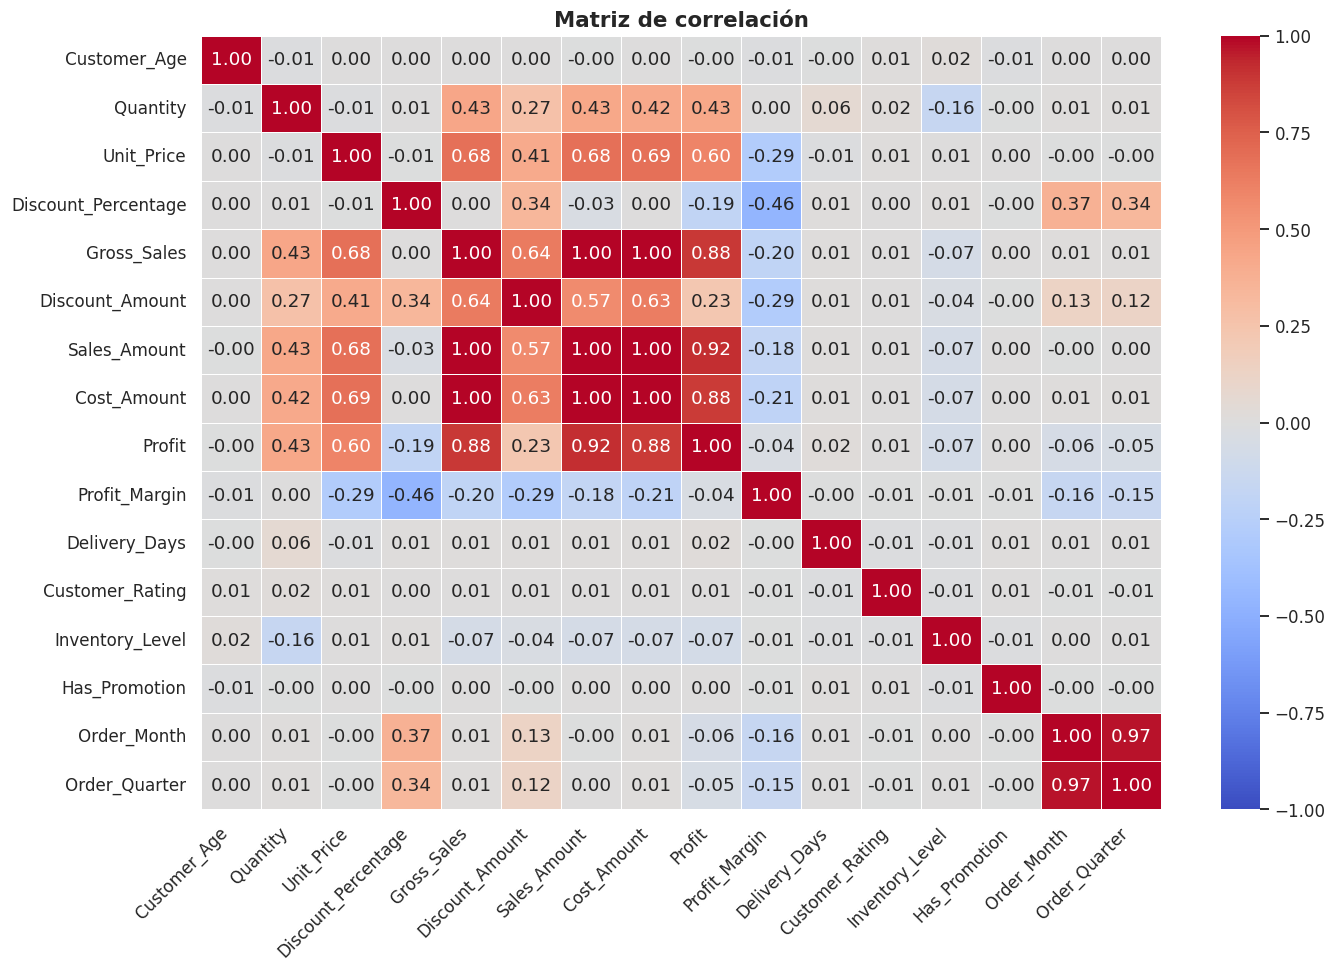

In [ ]:
variables_correlacion = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percentage",
    "Gross_Sales",
    "Discount_Amount",
    "Sales_Amount",
    "Cost_Amount",
    "Profit",
    "Profit_Margin",
    "Delivery_Days",
    "Customer_Rating",
    "Inventory_Level",
    "Has_Promotion",
    "Order_Month",
    "Order_Quarter"
]

correlaciones = (
    df_eda[variables_correlacion]
    .corr()
)

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlaciones,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Matriz de correlación",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.3 Correlaciones muy altas y variables redundantes

En este ejercicio consideramos una correlación absoluta superior a **0,90** como señal para revisar si dos variables están explicando prácticamente lo mismo.

No eliminamos columnas automáticamente: primero entendemos **por qué** están relacionadas.

Ejemplos esperados:

- `Gross_Sales` y `Sales_Amount` representan montos muy parecidos;
- `Sales_Amount` y `Cost_Amount` crecen juntas porque las ventas grandes suelen tener costos grandes;
- `Sales_Amount` y `Profit` están relacionadas por definición;
- `Order_Month` y `Order_Quarter` describen el mismo eje temporal con diferente nivel de detalle.

En un futuro modelo predictivo no conviene incluir todas estas variables simultáneamente.

In [ ]:
columnas = correlaciones.columns

pares_altos = []

for i in range(len(columnas)):
    for j in range(i + 1, len(columnas)):

        valor = correlaciones.iloc[i, j]

        if abs(valor) >= 0.90:
            pares_altos.append({
                "Variable_1": columnas[i],
                "Variable_2": columnas[j],
                "Correlacion": round(valor, 3)
            })

display(pd.DataFrame(pares_altos))

,Variable_1,Variable_2,Correlacion
0,Gross_Sales,Sales_Amount,0.996
1,Gross_Sales,Cost_Amount,0.999
2,Sales_Amount,Cost_Amount,0.996
3,Sales_Amount,Profit,0.917
4,Order_Month,Order_Quarter,0.973


## 3.4 Definición del target

Nuestro **target principal** será:

> ### `Profit_Margin`

La pregunta es:

> **¿Qué características están asociadas con una mayor rentabilidad porcentual?**

Elegimos margen porque permite comparar ventas grandes y pequeñas en una misma escala.

Sin embargo, el margen por sí solo puede ocultar diferencias muy grandes de volumen.  
Por eso, durante todo el EDA observaremos también:

- **`Sales_Amount`** → cuánto vendemos;
- **`Profit`** → cuánto dinero ganamos;
- **`Profit_Margin`** → qué tan eficientemente convertimos ventas en utilidad.

### Nota para futuros modelos

Como `Profit_Margin` se calcula usando `Profit` y `Sales_Amount`, esas variables **no deberían usarse como predictores de un modelo cuyo target sea el margen**.  
Sería darle al modelo parte de la respuesta.

Para el EDA sí las conservamos porque son métricas de negocio muy útiles.

## 3.5 Preparación del entorno SQL

Hasta este punto hemos trabajado principalmente con Pandas. Para practicar la misma lógica con SQL vamos a crear una base de datos temporal en memoria usando `sqlite3`.

No estamos creando un archivo adicional ni modificando el dataset. Simplemente tomamos algunas columnas de `df_eda` y las copiamos a una tabla llamada `ventas`.

La conexión se mantendrá abierta durante el notebook para poder ejecutar las cinco consultas SQL seleccionadas.

In [ ]:
import sqlite3

# Crear una base de datos temporal en memoria
conexion = sqlite3.connect(":memory:")

# Seleccionamos solamente las columnas que necesitaremos en SQL
columnas_sql = [
    "Transaction_ID",
    "Product_ID",
    "Product_Category",
    "Sales_Channel",
    "Customer_Age",
    "Sales_Amount",
    "Profit",
    "Discount_Percentage",
    "Order_Quarter"
]

df_sql = df_eda[columnas_sql].copy()

# Llevar el DataFrame a una tabla SQL llamada ventas
df_sql.to_sql(
    "ventas",
    conexion,
    if_exists="replace",
    index=False
)

print(
    "Registros cargados en la tabla SQL:",
    pd.read_sql_query(
        "SELECT COUNT(*) AS registros FROM ventas",
        conexion
    )["registros"][0]
)

Registros cargados en la tabla SQL: 18000


### ¿Por qué usamos SQLite?

SQLite es suficiente para este ejercicio porque permite ejecutar SQL directamente desde Python sin instalar un servidor de base de datos.

La sintaxis que usaremos —`SELECT`, `GROUP BY`, `CASE WHEN`, `WITH`, `SUM`, `AVG` y `ORDER BY`— es muy similar a la utilizada en otros motores de SQL.

# 4. Análisis exploratorio de datos (EDA)

Ahora comenzamos a responder preguntas de negocio.

En cada comparación intentaremos separar tres ideas:

1. **Volumen:** dónde vendemos más.
2. **Ganancia absoluta:** dónde obtenemos más dinero.
3. **Eficiencia:** dónde el margen es mejor.

## 4.1 Indicadores generales del negocio

Antes de segmentar los datos calculamos cuatro indicadores globales.

In [ ]:
ventas_totales = df_eda["Sales_Amount"].sum()
utilidad_total = df_eda["Profit"].sum()

margen_total = (
    utilidad_total
    / ventas_totales
    * 100
)

print(
    f"Ventas totales: ${ventas_totales:,.2f}"
)

print(
    f"Utilidad total: ${utilidad_total:,.2f}"
)

print(
    f"Margen global: {margen_total:.2f}%"
)

print(
    f"Transacciones: {len(df_eda):,}"
)

Ventas totales: $8,234,090.60
Utilidad total: $1,645,439.40
Margen global: 19.98%
Transacciones: 18,000


### Lectura general

Durante 2022–2025 el dataset registra aproximadamente:

- **$8,23 millones en ventas**;
- **$1,64 millones de utilidad**;
- un **margen agregado cercano al 20%**;
- **18.000 transacciones únicas** después de eliminar duplicados.

Estos números serán nuestra referencia para interpretar los siguientes análisis.

## 4.2 ¿Cómo se distribuyen las ventas?

En este punto queremos responder una pregunta sencilla:

> **¿Cuál es el valor habitual de una transacción y cómo se distribuyen las ventas?**

Usamos un **histograma** porque permite observar cuántas transacciones se concentran en diferentes rangos de valor.

El dataset contiene algunas ventas muy grandes que son válidas, pero si mostramos toda la escala el comportamiento de la mayoría de las transacciones queda comprimido hacia la izquierda.

Por eso, **únicamente para esta visualización**, mostraremos las ventas hasta el **percentil 95**.

Esto significa que:

- el 95% de las transacciones queda representado con una escala mucho más legible;
- el 5% de mayor valor no se muestra en esta figura;
- **ningún registro se elimina del dataset**;
- todas las transacciones siguen participando en los cálculos posteriores.

La comparación por canal se realizará más adelante, donde podremos analizarla de forma más clara.


In [ ]:
# Percentil 95: se utiliza únicamente para mejorar la visualización
limite_95 = (
    df_eda["Sales_Amount"]
    .quantile(0.95)
)

ventas_visual = df_eda[
    df_eda["Sales_Amount"] <= limite_95
].copy()

# Estas estadísticas sí utilizan TODO el dataset
mediana_ventas = df_eda["Sales_Amount"].median()
media_ventas = df_eda["Sales_Amount"].mean()

fig = px.histogram(
    ventas_visual,
    x="Sales_Amount",
    nbins=40,
    labels={
        "Sales_Amount": "Venta por transacción ($)"
    },
    title="Distribución del valor de las ventas"
)

# Limitar el eje X al rango que realmente queremos estudiar visualmente
fig.update_xaxes(
    range=[0, limite_95],
    title="Venta por transacción ($)"
)

fig.update_yaxes(
    title="Número de transacciones"
)

# Línea de la mediana
fig.add_vline(
    x=mediana_ventas,
    line_dash="dash",
    line_width=2,
    annotation_text=f"Mediana: ${mediana_ventas:,.0f}",
    annotation_position="top left"
)

# Línea del promedio
fig.add_vline(
    x=media_ventas,
    line_dash="dash",
    line_width=2,
    annotation_text=f"Promedio: ${media_ventas:,.0f}",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5,
    bargap=0.03
)

fig.show(renderer="colab")

print(
    f"Mediana de venta: ${mediana_ventas:,.2f}"
)

print(
    f"Promedio de venta: ${media_ventas:,.2f}"
)

print(
    f"Percentil 95 utilizado solo para visualizar: ${limite_95:,.2f}"
)


Mediana de venta: $168.84
Promedio de venta: $457.45
Percentil 95 utilizado solo para visualizar: $1,769.17


### ¿Qué observamos?

La mayor parte de las transacciones se concentra en valores relativamente bajos, mientras que existe un grupo menor de ventas con montos mucho mayores.

Esto genera una distribución **sesgada hacia la derecha**.

La diferencia entre las dos medidas centrales ayuda a entenderlo:

- la **mediana** representa el punto donde la mitad de las transacciones queda por debajo y la otra mitad por encima;
- el **promedio** aumenta debido a la presencia de ventas de mayor valor.

En este dataset el promedio es considerablemente mayor que la mediana. Por eso, para describir el valor de una venta “típica”, la mediana resulta más representativa.

> **Importante:** el percentil 95 se utiliza únicamente para ajustar la escala del gráfico. El 5% de las transacciones de mayor valor continúa presente en `df_eda` y participa en todos los cálculos posteriores.


## 4.3 Distribución del margen de utilidad

Ahora observamos el target `Profit_Margin`.

Mostramos el rango central entre los percentiles 1 y 99 solamente para que unos pocos valores extremos no compriman visualmente el histograma.

> No estamos eliminando esos registros del dataset.

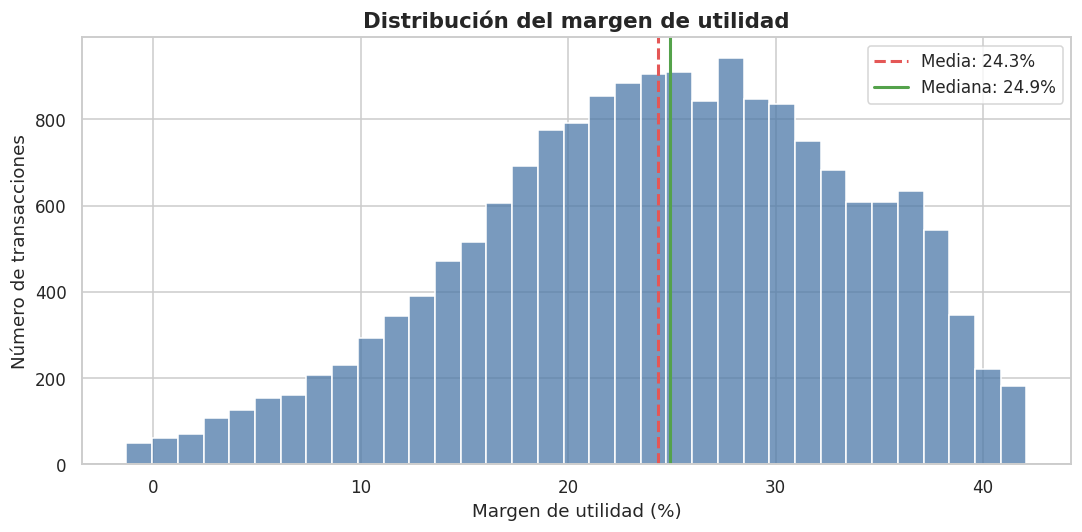

In [ ]:
limite_inferior = (
    df_eda["Profit_Margin"]
    .quantile(0.01)
)

limite_superior = (
    df_eda["Profit_Margin"]
    .quantile(0.99)
)

margen_visual = df_eda[
    df_eda["Profit_Margin"].between(
        limite_inferior,
        limite_superior
    )
]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=margen_visual,
    x="Profit_Margin",
    bins=35,
    color="#4C78A8",
    edgecolor="white"
)

media_margen = (
    df_eda["Profit_Margin"].mean()
)

mediana_margen = (
    df_eda["Profit_Margin"].median()
)

plt.axvline(
    media_margen,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Media: {media_margen:.1f}%"
)

plt.axvline(
    mediana_margen,
    color="#54A24B",
    linewidth=2,
    label=f"Mediana: {mediana_margen:.1f}%"
)

plt.title(
    "Distribución del margen de utilidad",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Margen de utilidad (%)")
plt.ylabel("Número de transacciones")
plt.legend()
plt.tight_layout()
plt.show()

## 4.4 ¿Qué variables numéricas se relacionan con el margen?

Aquí calculamos la correlación de varias variables con `Profit_Margin`.

Excluimos `Sales_Amount`, `Cost_Amount` y `Profit` como variables explicativas principales porque participan directamente en el cálculo económico del margen o están estrechamente relacionadas con él.

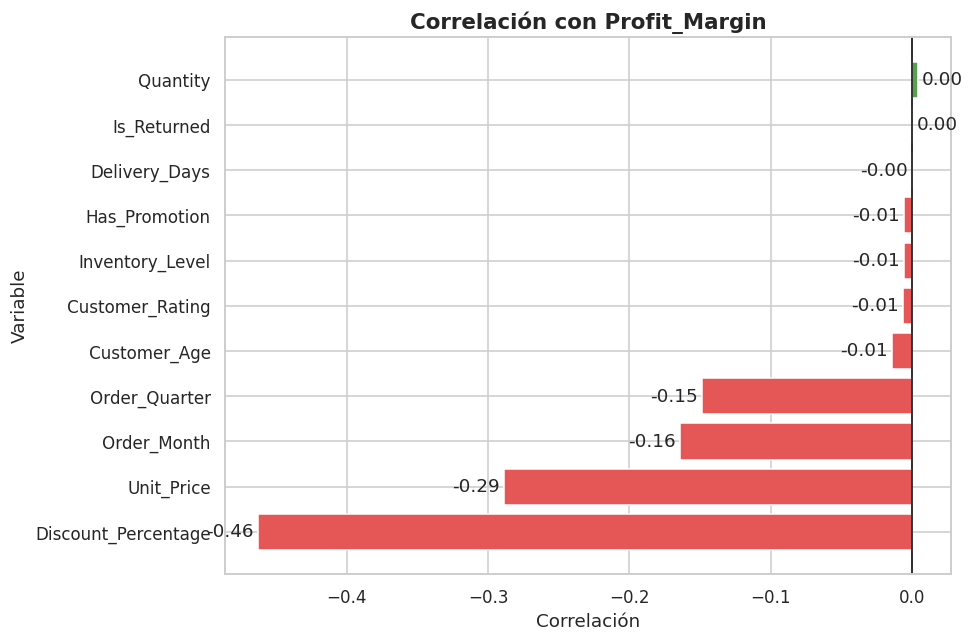

In [ ]:
variables_target = [
    "Customer_Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percentage",
    "Delivery_Days",
    "Customer_Rating",
    "Inventory_Level",
    "Has_Promotion",
    "Order_Month",
    "Order_Quarter",
    "Is_Returned",
    "Profit_Margin"
]

corr_target = (
    df_eda[variables_target]
    .corr()["Profit_Margin"]
    .drop("Profit_Margin")
    .sort_values()
)

plt.figure(figsize=(9, 6))

colores = [
    "#E45756" if valor < 0
    else "#54A24B"
    for valor in corr_target.values
]

barras = plt.barh(
    corr_target.index,
    corr_target.values,
    color=colores
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.bar_label(
    barras,
    labels=[
        f"{valor:.2f}"
        for valor in corr_target.values
    ],
    padding=3
)

plt.title(
    "Correlación con Profit_Margin",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Hallazgo principal

La relación numérica más clara es **negativa entre descuento y margen**.

Esto significa que, dentro de este dataset, las transacciones con mayores descuentos tienden a dejar una proporción menor de utilidad sobre la venta.

Este resultado será especialmente importante cuando analicemos el comportamiento del **Q4**.

## 4.5 Categorías de producto: volumen, utilidad y margen

Primero agrupamos por categoría.

Calculamos:

- ventas totales;
- utilidad total;
- margen agregado.

El margen agregado se calcula como:

> Utilidad total / Ventas totales × 100

Esto evita darle el mismo peso a una venta de $20 y a una venta de $5.000.

In [ ]:
categoria = (
    df_eda
    .groupby(
        "Product_Category",
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

categoria["Profit_Margin"] = (
    categoria["Profit"]
    / categoria["Sales_Amount"]
    * 100
)

categoria = categoria.sort_values(
    "Sales_Amount",
    ascending=False
)

display(categoria.round(2))

,Product_Category,Sales_Amount,Profit,Profit_Margin
1,Electronics,4922081.42,952110.92,19.34
2,Furniture,1986144.85,420015.02,21.15
3,Office Supplies,741774.85,144728.13,19.51
0,Appliances,584089.48,128585.33,22.01


In [ ]:
fig = px.bar(
    categoria,
    x="Product_Category",
    y=["Sales_Amount", "Profit"],
    barmode="group",
    text_auto=".2s",
    labels={
        "value": "Monto ($)",
        "variable": "Métrica",
        "Product_Category": "Categoría"
    },
    title="Ventas y utilidad por categoría"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


In [ ]:
fig = px.bar(
    categoria.sort_values(
        "Profit_Margin",
        ascending=False
    ),
    x="Product_Category",
    y="Profit_Margin",
    color="Product_Category",
    text="Profit_Margin",
    labels={
        "Profit_Margin": "Margen (%)",
        "Product_Category": "Categoría"
    },
    title="Margen de utilidad por categoría"
)

fig.update_traces(
    texttemplate="%{text:.1f}%"
)

fig.update_layout(
    template="plotly_white",
    height=450,
    showlegend=False,
    title_x=0.5
)

fig.show(renderer="colab")


### Interpretación

**Electronics** concentra ampliamente el mayor volumen de ventas y también la mayor utilidad monetaria.

Sin embargo, las diferencias de margen entre categorías son mucho menores que las diferencias de ventas.

Esto nos enseña algo importante:

> Una categoría puede ser muy importante para el negocio por su volumen aunque no tenga el margen porcentual más alto.

### Equivalente SQL — Caso 1: rentabilidad por categoría  
**Complejidad estimada: 4/10**

Este es el caso más sencillo de los cinco y funciona como punto de entrada.

En Pandas usamos `groupby()` para agrupar las transacciones por categoría, sumar las ventas y el Profit, y después calcular el margen. En SQL hacemos exactamente la misma idea con `GROUP BY`.

Lo importante es notar que el margen se calcula con los totales del grupo:

`SUM(Profit) / SUM(Sales_Amount) × 100`

y no como el promedio simple de los márgenes individuales.

In [ ]:
consulta_sql_categoria = '''
SELECT
    Product_Category,
    ROUND(SUM(Sales_Amount), 2) AS Sales_Amount,
    ROUND(SUM(Profit), 2) AS Profit,
    ROUND(
        SUM(Profit) * 100.0 / NULLIF(SUM(Sales_Amount), 0),
        2
    ) AS Profit_Margin
FROM ventas
GROUP BY Product_Category
ORDER BY Sales_Amount DESC;
'''

categoria_sql = pd.read_sql_query(
    consulta_sql_categoria,
    conexion
)

display(categoria_sql)

,Product_Category,Sales_Amount,Profit,Profit_Margin
0,Electronics,4922081.42,952110.92,19.34
1,Furniture,1986144.85,420015.02,21.15
2,Office Supplies,741774.85,144728.13,19.51
3,Appliances,584089.48,128585.33,22.01


### Lectura del resultado SQL

El resultado debe coincidir con la tabla obtenida en Pandas: `Electronics` concentra el mayor volumen de ventas y Profit, mientras que otras categorías pueden mostrar un margen porcentual ligeramente superior.

Esta consulta nos sirve para ver la equivalencia más directa entre:

- `groupby()` de Pandas;
- `GROUP BY` de SQL;
- `sum()` de Pandas;
- `SUM()` de SQL.

## 4.6 Canales de venta

Repetimos la misma lógica por canal para diferenciar:

- cuál vende más;
- cuál genera más utilidad;
- cuál convierte mejor las ventas en utilidad.

In [ ]:
canal = (
    df_eda
    .groupby(
        "Sales_Channel",
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

canal["Profit_Margin"] = (
    canal["Profit"]
    / canal["Sales_Amount"]
    * 100
)

canal = canal.sort_values(
    "Sales_Amount",
    ascending=False
)

display(canal.round(2))

,Sales_Channel,Sales_Amount,Profit,Profit_Margin
1,Online,3112092.21,629813.67,20.24
3,Retail Store,2449189.44,487427.54,19.90
0,B2B Portal,2121499.06,419770.48,19.79
2,Phone Order,551309.89,108427.71,19.67


In [ ]:
fig = px.bar(
    canal,
    x="Sales_Channel",
    y=["Sales_Amount", "Profit"],
    barmode="group",
    text_auto=".2s",
    labels={
        "value": "Monto ($)",
        "variable": "Métrica",
        "Sales_Channel": "Canal"
    },
    title="Ventas y utilidad por canal"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


### Interpretación

Los márgenes de los canales son muy similares, alrededor del 20%.

La principal diferencia entre canales está entonces en el **volumen de ventas**, no en una enorme ventaja porcentual de rentabilidad.

`Online` es el canal con mayor facturación y utilidad.

## 4.7 Descuento y rentabilidad

Como la correlación mostró una relación importante entre descuento y margen, analizamos esta variable con mayor detalle.

Un **boxplot** permite comparar la distribución del margen para cada nivel de descuento.

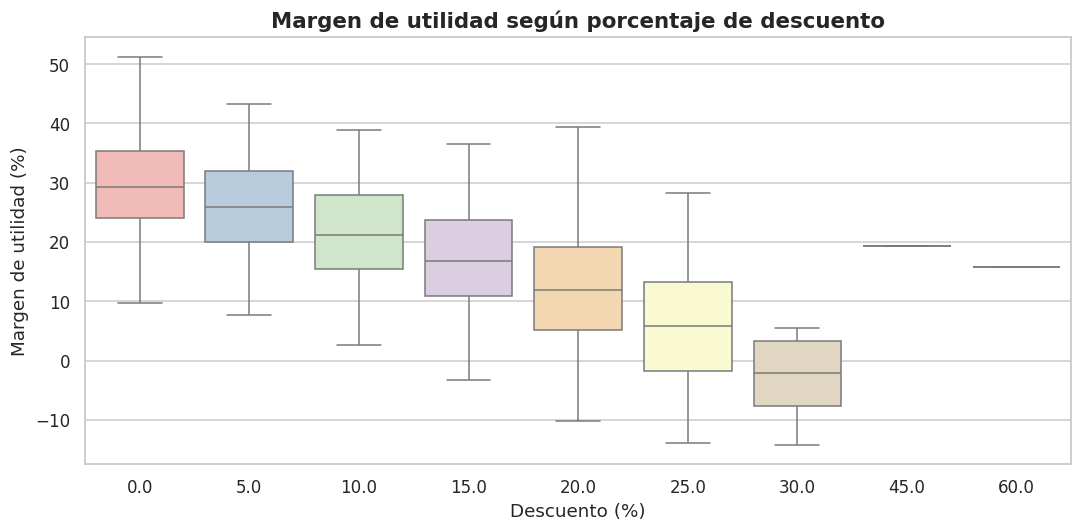

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_eda,
    x="Discount_Percentage",
    y="Profit_Margin",
    hue="Discount_Percentage",
    palette="Pastel1",
    legend=False,
    showfliers=False
)

plt.title(
    "Margen de utilidad según porcentaje de descuento",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Descuento (%)")
plt.ylabel("Margen de utilidad (%)")
plt.tight_layout()
plt.show()

### Cómo leer este gráfico

Cada caja resume muchas transacciones con el mismo nivel de descuento.

Si las cajas se desplazan hacia abajo a medida que aumenta el descuento, significa que el margen típico también disminuye.

Este patrón no demuestra por sí mismo causalidad, pero sí evidencia una asociación fuerte que merece investigación.

## 4.8 Evolución trimestral: ventas, utilidad y margen

Para observar el tiempo usamos trimestre en lugar de mes.

El trimestre reduce el ruido mensual y permite identificar patrones estacionales con mayor facilidad.

Primero analizamos **ventas y utilidad**, porque ambas están expresadas en dinero.

In [ ]:
trimestral = (
    df_eda
    .groupby("Year_Quarter")
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount_Percentage", "mean")
    )
    .reset_index()
)

trimestral["Profit_Margin"] = (
    trimestral["Profit"]
    / trimestral["Sales_Amount"]
    * 100
)

display(trimestral.round(2))

,Year_Quarter,Sales_Amount,Profit,Avg_Discount,Profit_Margin
0,2022-Q1,360742.91,78241.57,4.63,21.69
1,2022-Q2,503231.43,106888.27,4.39,21.24
2,2022-Q3,475399.25,110140.33,2.77,23.17
3,2022-Q4,669269.95,111306.47,10.85,16.63
4,2023-Q1,427002.44,90209.73,4.51,21.13
5,2023-Q2,501634.53,104508.97,4.71,20.83
6,2023-Q3,440898.68,101040.71,2.98,22.92
7,2023-Q4,651817.23,105499.60,11.02,16.19
8,2024-Q1,404629.16,85448.39,4.45,21.12
9,2024-Q2,422519.38,90655.64,4.77,21.46


In [ ]:
fig = px.line(
    trimestral,
    x="Year_Quarter",
    y=["Sales_Amount", "Profit"],
    markers=True,
    labels={
        "value": "Monto ($)",
        "variable": "Métrica",
        "Year_Quarter": "Trimestre"
    },
    title="Evolución trimestral de ventas y utilidad"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


In [ ]:
fig = px.line(
    trimestral,
    x="Year_Quarter",
    y="Profit_Margin",
    markers=True,
    text="Profit_Margin",
    labels={
        "Profit_Margin": "Margen (%)",
        "Year_Quarter": "Trimestre"
    },
    title="Evolución trimestral del margen"
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="top center"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


### Primer hallazgo temporal

El gráfico muestra un patrón repetido:

> **Los Q4 presentan un margen menor que los demás trimestres.**

Pero mirar solo el margen no es suficiente.

Q4 también suele ser un periodo de mucho mayor volumen.  
Por eso necesitamos investigar qué está ocurriendo con ventas, utilidad y descuentos al mismo tiempo.

## 4.9 Investigación especial: ¿por qué Q4 tiene menor margen?

Formulamos una hipótesis:

> **¿La menor rentabilidad de Q4 está relacionada con una estrategia de descuentos más agresiva?**

Para investigarla construiremos primero un resumen por número de trimestre.

Calcularemos:

- ventas;
- utilidad;
- margen;
- descuento promedio;
- porcentaje de transacciones que tienen algún descuento;
- porcentaje de transacciones con código promocional.

In [ ]:
resumen_q = (
    df_eda
    .groupby("Order_Quarter")
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount_Percentage", "mean"),
        Transactions=("Transaction_ID", "count"),
        Has_Promotion=("Has_Promotion", "mean")
    )
    .reset_index()
)

resumen_q["Profit_Margin"] = (
    resumen_q["Profit"]
    / resumen_q["Sales_Amount"]
    * 100
)

porcentaje_descuento = (
    df_eda
    .assign(
        Has_Discount=(
            df_eda["Discount_Percentage"] > 0
        ).astype(int)
    )
    .groupby("Order_Quarter")["Has_Discount"]
    .mean()
    .reset_index()
)

porcentaje_descuento["Pct_With_Discount"] = (
    porcentaje_descuento["Has_Discount"]
    * 100
)

resumen_q = resumen_q.merge(
    porcentaje_descuento[
        ["Order_Quarter", "Pct_With_Discount"]
    ],
    on="Order_Quarter"
)

resumen_q["Pct_With_Promotion"] = (
    resumen_q["Has_Promotion"]
    * 100
)

display(
    resumen_q[[
        "Order_Quarter",
        "Sales_Amount",
        "Profit",
        "Profit_Margin",
        "Avg_Discount",
        "Pct_With_Discount",
        "Pct_With_Promotion"
    ]].round(2)
)

,Order_Quarter,Sales_Amount,Profit,Profit_Margin,Avg_Discount,Pct_With_Discount,Pct_With_Promotion
0,1,1710344.69,365460.28,21.37,4.55,50.51,46.14
1,2,1947121.45,411783.53,21.15,4.64,50.72,46.32
2,3,1879087.69,434223.50,23.11,2.82,35.16,46.04
3,4,2697536.77,433972.09,16.09,10.91,82.85,45.79


### Resultado clave

Al agrupar los cuatro años aparece un contraste claro:

- Q4 concentra las mayores ventas;
- el crecimiento de utilidad es mucho menor que el crecimiento de ventas;
- el margen baja aproximadamente a **16%**;
- el descuento promedio sube a aproximadamente **11%**;
- más del **80% de las transacciones de Q4** tienen algún descuento.

En Q1–Q3 el descuento promedio ronda el 4% y menos de la mitad de las transacciones tiene descuento.

In [ ]:
comparacion_descuento = resumen_q[[
    "Order_Quarter",
    "Profit_Margin",
    "Avg_Discount"
]].copy()

comparacion_descuento["Quarter"] = (
    "Q"
    + comparacion_descuento[
        "Order_Quarter"
    ].astype(str)
)

fig = px.line(
    comparacion_descuento,
    x="Quarter",
    y=["Profit_Margin", "Avg_Discount"],
    markers=True,
    text="value",
    labels={
        "value": "Porcentaje (%)",
        "variable": "Indicador",
        "Quarter": "Trimestre"
    },
    title="Margen vs. descuento promedio por trimestre"
)

fig.update_traces(
    texttemplate="%{text:.1f}%"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


### ¿Qué muestra la gráfica?

Q4 es el trimestre donde ocurre simultáneamente:

- el **mayor descuento promedio**;
- el **menor margen de utilidad**.

La relación es coherente con la correlación negativa que observamos anteriormente entre descuento y margen.

Sin embargo, todavía debemos descartar otra explicación:

> Tal vez Q4 simplemente vende una mezcla diferente de productos con menor margen.

Para comprobarlo, compararemos Q4 contra Q1–Q3 dentro de cada categoría.

In [ ]:
df_eda["Period_Group"] = np.where(
    df_eda["Order_Quarter"] == 4,
    "Q4",
    "Q1-Q3"
)

categoria_periodo = (
    df_eda
    .groupby(
        ["Product_Category", "Period_Group"],
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount_Percentage", "mean")
    )
    .reset_index()
)

categoria_periodo["Profit_Margin"] = (
    categoria_periodo["Profit"]
    / categoria_periodo["Sales_Amount"]
    * 100
)

display(categoria_periodo.round(2))

,Product_Category,Period_Group,Sales_Amount,Profit,Avg_Discount,Profit_Margin
0,Appliances,Q1-Q3,409759.70,97208.52,4.04,23.72
1,Appliances,Q4,174329.78,31376.81,11.07,18.00
2,Electronics,Q1-Q3,3292089.95,698514.31,4.01,21.22
3,Electronics,Q4,1629991.47,253596.61,10.73,15.56
4,Furniture,Q1-Q3,1323250.04,306328.79,3.91,23.15
5,Furniture,Q4,662894.81,113686.23,10.84,17.15
6,Office Supplies,Q1-Q3,511454.14,109415.69,4.02,21.39
7,Office Supplies,Q4,230320.71,35312.44,11.21,15.33


In [ ]:
fig = px.bar(
    categoria_periodo,
    x="Product_Category",
    y="Profit_Margin",
    color="Period_Group",
    barmode="group",
    text="Profit_Margin",
    labels={
        "Product_Category": "Categoría",
        "Profit_Margin": "Margen (%)",
        "Period_Group": "Periodo"
    },
    title="Margen por categoría: Q4 vs Q1-Q3"
)

fig.update_traces(
    texttemplate="%{text:.1f}%"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


In [ ]:
fig = px.bar(
    categoria_periodo,
    x="Product_Category",
    y="Avg_Discount",
    color="Period_Group",
    barmode="group",
    text="Avg_Discount",
    labels={
        "Product_Category": "Categoría",
        "Avg_Discount": "Descuento promedio (%)",
        "Period_Group": "Periodo"
    },
    title="Descuento promedio por categoría: Q4 vs Q1-Q3"
)

fig.update_traces(
    texttemplate="%{text:.1f}%"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


### Conclusión del análisis de Q4

El patrón se mantiene en **todas las categorías**:

- Q4 tiene descuentos promedio mayores;
- Q4 presenta márgenes menores.

También comprobamos el patrón a nivel de producto.

### Equivalente SQL — Caso 3: Q4 vs. Q1–Q3 por categoría  
**Complejidad estimada: 7/10**

Aquí la consulta ya requiere un paso adicional: necesitamos crear una clasificación que no existe originalmente en la tabla.

Con `CASE WHEN` separamos cada transacción en dos grupos:

- `Q4`;
- `Q1-Q3`.

Después agrupamos simultáneamente por categoría y por ese nuevo grupo. Así podemos comparar ventas, Profit, descuento promedio y margen dentro de cada categoría.

In [ ]:
consulta_sql_q4_categoria = '''
WITH base AS (
    SELECT
        Product_Category,
        CASE
            WHEN Order_Quarter = 4 THEN 'Q4'
            ELSE 'Q1-Q3'
        END AS Period_Group,
        Sales_Amount,
        Profit,
        Discount_Percentage
    FROM ventas
)

SELECT
    Product_Category,
    Period_Group,
    ROUND(SUM(Sales_Amount), 2) AS Sales_Amount,
    ROUND(SUM(Profit), 2) AS Profit,
    ROUND(AVG(Discount_Percentage), 2) AS Avg_Discount,
    ROUND(
        SUM(Profit) * 100.0 / NULLIF(SUM(Sales_Amount), 0),
        2
    ) AS Profit_Margin
FROM base
GROUP BY Product_Category, Period_Group
ORDER BY Product_Category, Period_Group;
'''

q4_categoria_sql = pd.read_sql_query(
    consulta_sql_q4_categoria,
    conexion
)

display(q4_categoria_sql)

,Product_Category,Period_Group,Sales_Amount,Profit,Avg_Discount,Profit_Margin
0,Appliances,Q1-Q3,409759.70,97208.52,4.04,23.72
1,Appliances,Q4,174329.78,31376.81,11.07,18.00
2,Electronics,Q1-Q3,3292089.95,698514.31,4.01,21.22
3,Electronics,Q4,1629991.47,253596.61,10.73,15.56
4,Furniture,Q1-Q3,1323250.04,306328.79,3.91,23.15
5,Furniture,Q4,662894.81,113686.23,10.84,17.15
6,Office Supplies,Q1-Q3,511454.14,109415.69,4.02,21.39
7,Office Supplies,Q4,230320.71,35312.44,11.21,15.33


### ¿Qué aporta esta consulta?

El `WITH base AS (...)` crea una tabla temporal solamente para organizar la lógica. Dentro de ella usamos `CASE WHEN` para construir `Period_Group`.

Después el `SELECT` principal realiza las agregaciones.

Al igual que en Pandas, el resultado permite ver que el patrón de **mayor descuento y menor margen en Q4** aparece dentro de las diferentes categorías. Esto ayuda a descartar que la caída del margen se explique solamente porque en Q4 se venda una combinación distinta de categorías.

In [ ]:
producto_periodo = (
    df_eda
    .groupby(
        ["Product_ID", "Period_Group"],
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount_Percentage", "mean")
    )
    .reset_index()
)

producto_periodo["Profit_Margin"] = (
    producto_periodo["Profit"]
    / producto_periodo["Sales_Amount"]
    * 100
)

comparacion_producto = (
    producto_periodo
    .pivot(
        index="Product_ID",
        columns="Period_Group",
        values=[
            "Avg_Discount",
            "Profit_Margin"
        ]
    )
)

condicion = (
    (
        comparacion_producto[
            ("Avg_Discount", "Q4")
        ]
        >
        comparacion_producto[
            ("Avg_Discount", "Q1-Q3")
        ]
    )
    &
    (
        comparacion_producto[
            ("Profit_Margin", "Q4")
        ]
        <
        comparacion_producto[
            ("Profit_Margin", "Q1-Q3")
        ]
    )
)

print(
    "Productos con mayor descuento y menor margen en Q4:",
    condicion.sum(),
    "de",
    len(condicion)
)

Productos con mayor descuento y menor margen en Q4: 28 de 28


El patrón aparece en **los 28 productos** del dataset.

Por eso, la explicación no parece ser únicamente un cambio en el mix de productos.

La evidencia descriptiva sugiere que:

> **Q4 es la temporada de mayor volumen, pero los descuentos más agresivos reducen la eficiencia de esa venta.**

Esto no demuestra causalidad definitiva, pero es uno de los hallazgos más fuertes del EDA.

### Equivalente SQL — Caso 5: validar el patrón Q4 en los productos  
**Complejidad estimada: 9/10**

Esta es la consulta SQL más completa del notebook.

Queremos responder:

> **¿En cuántos productos el descuento promedio es mayor en Q4 y, al mismo tiempo, el margen es menor que en Q1–Q3?**

Para hacerlo necesitamos calcular cuatro valores por producto:

1. descuento promedio en Q4;
2. descuento promedio en Q1–Q3;
3. margen agregado en Q4;
4. margen agregado en Q1–Q3.

Después comparamos esos resultados con un segundo `CASE WHEN`.

Usamos una CTE (`WITH`) para dividir la consulta en pasos. Es una forma de hacer una consulta compleja más fácil de leer.

In [ ]:
consulta_sql_productos = '''
WITH resumen_producto AS (
    SELECT
        Product_ID,

        AVG(
            CASE
                WHEN Order_Quarter = 4
                THEN Discount_Percentage
            END
        ) AS Discount_Q4,

        AVG(
            CASE
                WHEN Order_Quarter <> 4
                THEN Discount_Percentage
            END
        ) AS Discount_Q1_Q3,

        SUM(
            CASE
                WHEN Order_Quarter = 4
                THEN Profit
                ELSE 0
            END
        ) * 100.0
        /
        NULLIF(
            SUM(
                CASE
                    WHEN Order_Quarter = 4
                    THEN Sales_Amount
                    ELSE 0
                END
            ),
            0
        ) AS Margin_Q4,

        SUM(
            CASE
                WHEN Order_Quarter <> 4
                THEN Profit
                ELSE 0
            END
        ) * 100.0
        /
        NULLIF(
            SUM(
                CASE
                    WHEN Order_Quarter <> 4
                    THEN Sales_Amount
                    ELSE 0
                END
            ),
            0
        ) AS Margin_Q1_Q3

    FROM ventas
    GROUP BY Product_ID
),

comparacion AS (
    SELECT
        Product_ID,
        ROUND(Discount_Q4, 2) AS Discount_Q4,
        ROUND(Discount_Q1_Q3, 2) AS Discount_Q1_Q3,
        ROUND(Margin_Q4, 2) AS Margin_Q4,
        ROUND(Margin_Q1_Q3, 2) AS Margin_Q1_Q3,

        CASE
            WHEN Discount_Q4 > Discount_Q1_Q3
             AND Margin_Q4 < Margin_Q1_Q3
            THEN 1
            ELSE 0
        END AS Cumple_Patron

    FROM resumen_producto
)

SELECT
    *,
    SUM(Cumple_Patron) OVER () AS Productos_Que_Cumplen,
    COUNT(*) OVER () AS Total_Productos
FROM comparacion
ORDER BY Product_ID;
'''

productos_sql = pd.read_sql_query(
    consulta_sql_productos,
    conexion
)

display(productos_sql)

,Product_ID,Discount_Q4,Discount_Q1_Q3,Margin_Q4,Margin_Q1_Q3,Cumple_Patron,Productos_Que_Cumplen,Total_Productos
0,P001,9.96,3.92,13.44,18.87,1,28,28
1,P002,11.20,4.03,14.63,20.76,1,28,28
2,P003,10.44,4.39,11.17,16.44,1,28,28
3,P004,11.12,4.22,15.74,21.35,1,28,28
4,P005,10.73,3.81,26.82,31.66,1,28,28
5,P006,10.76,3.74,30.75,35.68,1,28,28
6,P007,10.64,3.87,22.03,28.05,1,28,28
7,P008,10.29,3.97,20.89,26.22,1,28,28
8,P009,11.66,3.91,17.48,24.03,1,28,28
9,P010,9.68,4.08,16.33,21.93,1,28,28


### Interpretación

La consulta devuelve una fila por producto y una columna `Cumple_Patron`:

- `1` significa que en ese producto Q4 tiene mayor descuento y menor margen;
- `0` significa que alguna de esas dos condiciones no se cumple.

Las dos últimas columnas usan funciones de ventana (`OVER()`) para mostrar en todas las filas cuántos productos cumplen el patrón y cuántos productos fueron evaluados.

El resultado reproduce el hallazgo obtenido con Pandas: **los 28 productos cumplen las dos condiciones**.

Esto hace que el patrón sea más interesante, porque no depende de uno o dos productos particulares. Aun así, sigue siendo una asociación descriptiva y no una prueba de causalidad.

## 4.10 Productos: ¿cuáles mueven más dinero?

A nivel de producto mostramos los 10 con mayores ventas.

Nuevamente observamos las tres métricas para evitar confundir volumen con eficiencia.

In [ ]:
producto = (
    df_eda
    .groupby(
        "Product_Name",
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

producto["Profit_Margin"] = (
    producto["Profit"]
    / producto["Sales_Amount"]
    * 100
)

top_productos = (
    producto
    .sort_values(
        "Sales_Amount",
        ascending=False
    )
    .head(10)
)

display(top_productos.round(2))

,Product_Name,Sales_Amount,Profit,Profit_Margin
0,AeroBook 14 Laptop,1382381.54,234632.00,16.97
21,ProBook 16 Laptop,1346439.33,251757.02,18.70
7,EdgeTab 11 Tablet,675690.83,100538.15,14.88
24,Standing Desk,588721.39,118578.66,20.14
11,Meeting Table,530253.01,82509.73,15.56
27,Vision 27 Monitor,455769.38,89674.53,19.68
14,Office Chair Pro,436645.44,95708.07,21.92
20,Printer Plus,255368.19,35772.50,14.01
1,Air Purifier,236656.52,51163.35,21.62
9,Filing Cabinet,222637.74,55425.35,24.89


In [ ]:
fig = px.bar(
    top_productos.sort_values("Sales_Amount"),
    x=["Sales_Amount", "Profit"],
    y="Product_Name",
    barmode="group",
    orientation="h",
    labels={
        "value": "Monto ($)",
        "variable": "Métrica",
        "Product_Name": "Producto"
    },
    title="Top 10 productos por ventas"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    title_x=0.5
)

fig.show(renderer="colab")


## 4.11 Segmentos de clientes

Ahora analizamos si los tipos de cliente generan diferencias importantes.

Esta comparación es especialmente útil porque puede orientar estrategias comerciales.

In [ ]:
segmento = (
    df_eda
    .groupby(
        "Customer_Segment",
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

segmento["Profit_Margin"] = (
    segmento["Profit"]
    / segmento["Sales_Amount"]
    * 100
)

segmento = segmento.sort_values(
    "Sales_Amount",
    ascending=False
)

display(segmento.round(2))

,Customer_Segment,Sales_Amount,Profit,Profit_Margin
0,Consumer,3666739.39,737660.17,20.12
5,Small Business,1421953.05,287598.58,20.23
4,Returning Customer,1115273.90,224109.25,20.09
1,Corporate,942132.17,175673.11,18.65
2,New Customer,708173.63,141279.15,19.95
3,Premium,379818.46,79119.14,20.83


In [ ]:
fig = px.bar(
    segmento,
    x="Customer_Segment",
    y=["Sales_Amount", "Profit"],
    barmode="group",
    text_auto=".2s",
    labels={
        "value": "Monto ($)",
        "variable": "Métrica",
        "Customer_Segment": "Segmento"
    },
    title="Ventas y utilidad por segmento"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


### Interpretación

Los márgenes por segmento son relativamente cercanos entre sí.

La diferencia más importante vuelve a estar en **cuánto compra cada segmento**, no solamente en el porcentaje de margen.

El segmento `Consumer` concentra el mayor volumen.

## 4.12 Rango de edad: ventas, utilidad y margen

Esta sección agrega una dimensión de cliente al análisis.

Queremos responder dos preguntas:

1. **¿Qué edades concentran más ventas y utilidad?**
2. **¿Qué edades presentan mejor margen?**

Son preguntas diferentes.

In [ ]:
edad = (
    df_eda
    .groupby(
        "Age_Group",
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum"),
        Transactions=("Transaction_ID", "count")
    )
    .reset_index()
)

edad["Profit_Margin"] = (
    edad["Profit"]
    / edad["Sales_Amount"]
    * 100
)

display(edad.round(2))

,Age_Group,Sales_Amount,Profit,Transactions,Profit_Margin
0,18-25,891480.57,178192.18,1961,19.99
1,26-35,2233463.56,454988.88,4801,20.37
2,36-45,2961137.31,586660.51,6487,19.81
3,46-55,1650162.06,324681.63,3593,19.68
4,56+,497847.10,100916.20,1158,20.27


In [ ]:
fig = px.bar(
    edad,
    x="Age_Group",
    y=["Sales_Amount", "Profit"],
    barmode="group",
    text_auto=".2s",
    labels={
        "value": "Monto ($)",
        "variable": "Métrica",
        "Age_Group": "Rango de edad"
    },
    title="Ventas y utilidad por rango de edad"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


In [ ]:
fig = px.bar(
    edad,
    x="Age_Group",
    y="Profit_Margin",
    color="Age_Group",
    text="Profit_Margin",
    labels={
        "Profit_Margin": "Margen (%)",
        "Age_Group": "Rango de edad"
    },
    title="Margen de utilidad por rango de edad"
)

fig.update_traces(
    texttemplate="%{text:.1f}%"
)

fig.update_layout(
    template="plotly_white",
    height=450,
    showlegend=False,
    title_x=0.5
)

fig.show(renderer="colab")


### Interpretación

El grupo **36–45** concentra el mayor volumen de ventas y utilidad.

Sin embargo, los márgenes entre edades son muy parecidos.

Esto significa que la edad parece explicar mejor el **volumen de negocio** que grandes diferencias de rentabilidad porcentual.

### Equivalente SQL — Caso 2: rentabilidad por rango de edad  
**Complejidad estimada: 6/10**

En Pandas utilizamos `pd.cut()` para transformar la edad en rangos. En SQL podemos construir los mismos grupos mediante `CASE WHEN`.

Primero clasificamos cada registro en un rango de edad y luego calculamos:

- ventas totales;
- Profit total;
- número de transacciones;
- margen agregado.

También creamos `Age_Order` únicamente para conservar el orden lógico de los rangos en el resultado.

In [ ]:
consulta_sql_edad = '''
WITH edades AS (
    SELECT
        CASE
            WHEN Customer_Age BETWEEN 18 AND 25 THEN '18-25'
            WHEN Customer_Age BETWEEN 26 AND 35 THEN '26-35'
            WHEN Customer_Age BETWEEN 36 AND 45 THEN '36-45'
            WHEN Customer_Age BETWEEN 46 AND 55 THEN '46-55'
            ELSE '56+'
        END AS Age_Group,

        CASE
            WHEN Customer_Age BETWEEN 18 AND 25 THEN 1
            WHEN Customer_Age BETWEEN 26 AND 35 THEN 2
            WHEN Customer_Age BETWEEN 36 AND 45 THEN 3
            WHEN Customer_Age BETWEEN 46 AND 55 THEN 4
            ELSE 5
        END AS Age_Order,

        Transaction_ID,
        Sales_Amount,
        Profit
    FROM ventas
)

SELECT
    Age_Group,
    ROUND(SUM(Sales_Amount), 2) AS Sales_Amount,
    ROUND(SUM(Profit), 2) AS Profit,
    COUNT(Transaction_ID) AS Transactions,
    ROUND(
        SUM(Profit) * 100.0 / NULLIF(SUM(Sales_Amount), 0),
        2
    ) AS Profit_Margin
FROM edades
GROUP BY Age_Group, Age_Order
ORDER BY Age_Order;
'''

edad_sql = pd.read_sql_query(
    consulta_sql_edad,
    conexion
)

display(edad_sql)

,Age_Group,Sales_Amount,Profit,Transactions,Profit_Margin
0,18-25,891480.57,178192.18,1961,19.99
1,26-35,2233463.56,454988.88,4801,20.37
2,36-45,2961137.31,586660.51,6487,19.81
3,46-55,1650162.06,324681.63,3593,19.68
4,56+,497847.10,100916.20,1158,20.27


### Lectura del resultado SQL

La consulta reproduce el mismo comportamiento visto con Pandas: el rango de **36–45 años** concentra el mayor volumen de ventas y Profit, pero los márgenes porcentuales de los grupos son bastante cercanos.

Este ejemplo es útil porque muestra una equivalencia muy clara entre:

- `pd.cut()` en Pandas;
- `CASE WHEN` en SQL.

## 4.13 Países

La geografía puede ser importante aunque los márgenes sean parecidos.

Un país puede ser estratégico porque representa una gran parte del volumen total.

In [ ]:
pais = (
    df_eda
    .groupby(
        "Country",
        observed=True
    )
    .agg(
        Sales_Amount=("Sales_Amount", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

pais["Profit_Margin"] = (
    pais["Profit"]
    / pais["Sales_Amount"]
    * 100
)

pais = pais.sort_values(
    "Sales_Amount",
    ascending=False
)

display(pais.round(2))

,Country,Sales_Amount,Profit,Profit_Margin
5,United States,3503885.80,699600.24,19.97
4,United Kingdom,1326891.54,269790.34,20.33
1,Canada,1199510.15,240793.71,20.07
3,Germany,965192.00,189543.85,19.64
2,France,725734.88,144662.55,19.93
0,Australia,512876.23,101048.71,19.70


In [ ]:
fig = px.bar(
    pais,
    x="Country",
    y=["Sales_Amount", "Profit"],
    barmode="group",
    text_auto=".2s",
    labels={
        "value": "Monto ($)",
        "variable": "Métrica",
        "Country": "País"
    },
    title="Ventas y utilidad por país"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title_x=0.5
)

fig.show(renderer="colab")


### Interpretación

Estados Unidos concentra el mayor volumen de ventas y utilidad.

Los márgenes entre países son bastante similares.

Por lo tanto, la relevancia geográfica se explica principalmente por **escala**, no por enormes diferencias de eficiencia.

## 4.14 Categoría y canal

Finalmente combinamos dos dimensiones.

Una tabla dinámica (`pivot_table`) permite comparar una métrica en forma de matriz.

Primero observamos ventas.

/tmp/ipykernel_5791/2662467106.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



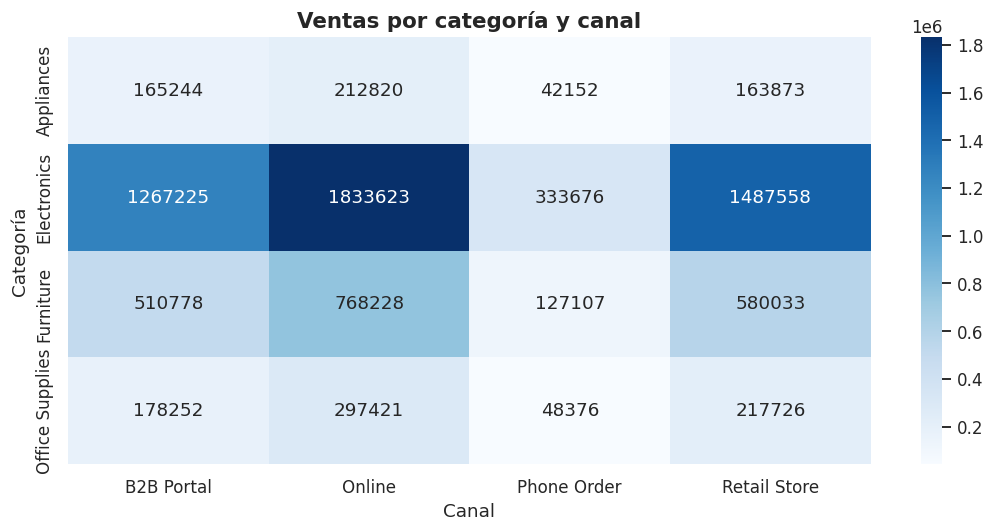

In [ ]:
tabla_ventas = pd.pivot_table(
    df_eda,
    values="Sales_Amount",
    index="Product_Category",
    columns="Sales_Channel",
    aggfunc="sum"
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    tabla_ventas,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title(
    "Ventas por categoría y canal",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Canal")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

Después observamos margen.

Esto nos permite comparar si las combinaciones que más venden son también las más eficientes.

/tmp/ipykernel_5791/2245387251.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



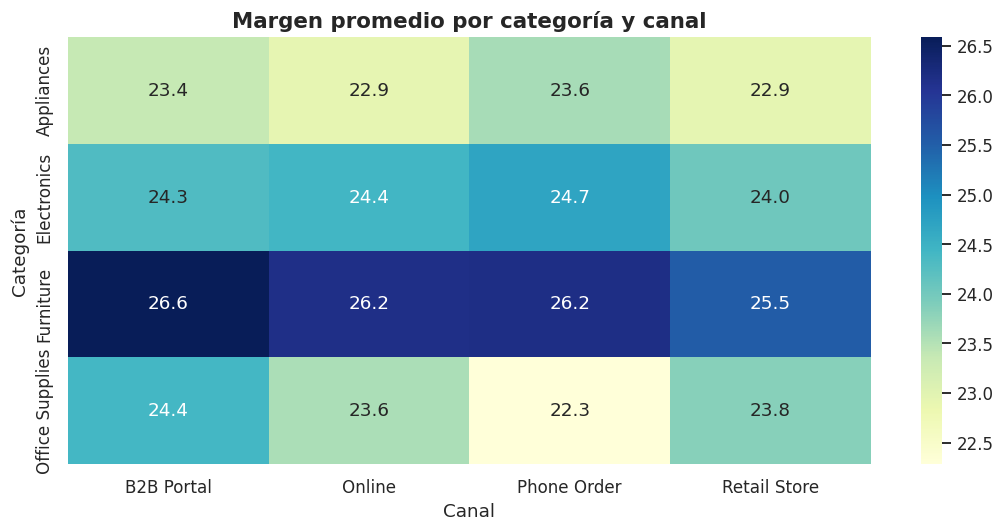

In [ ]:
tabla_margen = pd.pivot_table(
    df_eda,
    values="Profit_Margin",
    index="Product_Category",
    columns="Sales_Channel",
    aggfunc="mean"
).round(2)

plt.figure(figsize=(10, 5))

sns.heatmap(
    tabla_margen,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title(
    "Margen promedio por categoría y canal",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Canal")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

### Equivalente SQL — Caso 4: categoría × canal en formato tipo pivot  
**Complejidad estimada: 8/10**

En Pandas usamos `pivot_table()` para convertir los canales de venta en columnas.

SQLite no tiene una instrucción `PIVOT` directa como otros motores de base de datos, por lo que podemos construir el mismo resultado mediante **agregación condicional**.

La idea es sencilla: dentro de cada categoría sumamos `Sales_Amount` solamente cuando la transacción pertenece al canal correspondiente.

In [ ]:
consulta_sql_pivot = '''
SELECT
    Product_Category,

    ROUND(
        SUM(
            CASE
                WHEN Sales_Channel = 'Online'
                THEN Sales_Amount
                ELSE 0
            END
        ),
        2
    ) AS Online,

    ROUND(
        SUM(
            CASE
                WHEN Sales_Channel = 'Retail Store'
                THEN Sales_Amount
                ELSE 0
            END
        ),
        2
    ) AS Retail_Store,

    ROUND(
        SUM(
            CASE
                WHEN Sales_Channel = 'B2B Portal'
                THEN Sales_Amount
                ELSE 0
            END
        ),
        2
    ) AS B2B_Portal,

    ROUND(
        SUM(
            CASE
                WHEN Sales_Channel = 'Phone Order'
                THEN Sales_Amount
                ELSE 0
            END
        ),
        2
    ) AS Phone_Order

FROM ventas
GROUP BY Product_Category
ORDER BY Product_Category;
'''

pivot_sql = pd.read_sql_query(
    consulta_sql_pivot,
    conexion
)

display(pivot_sql)

,Product_Category,Online,Retail_Store,B2B_Portal,Phone_Order
0,Appliances,212819.98,163873.48,165244.17,42151.85
1,Electronics,1833623.16,1487557.64,1267224.88,333675.74
2,Furniture,768227.93,580032.69,510777.59,127106.64
3,Office Supplies,297421.14,217725.63,178252.42,48375.66


### ¿Cómo leer esta consulta?

Cada bloque `SUM(CASE WHEN...)` funciona como una columna del `pivot_table()`.

Por ejemplo, la columna `Online` suma `Sales_Amount` únicamente cuando `Sales_Channel = 'Online'`. Si la fila pertenece a otro canal, aporta cero a esa columna.

El resultado tiene la misma estructura conceptual que nuestra tabla dinámica de Pandas y puede utilizarse como fuente para construir el mismo heatmap.

# 5. Conclusiones generales

Después de analizar ventas, utilidad y margen podemos construir una lectura más completa del negocio.

## 1. Volumen y rentabilidad no son lo mismo

Las diferencias entre categorías, canales, edades y países son mucho más grandes en **ventas** que en **margen**.

Esto significa que varias dimensiones generan valor principalmente porque mueven mucho volumen, no porque tengan una eficiencia porcentual radicalmente distinta.

---

## 2. Electronics domina por escala

Es la categoría con mayor facturación y mayor utilidad monetaria.

Sin embargo, no tiene el mayor margen porcentual.

Por eso sería incorrecto evaluar una categoría solamente por margen.

---

## 3. Online es el canal más grande

El canal Online genera la mayor cantidad de ventas y utilidad.

Los márgenes por canal están muy cerca entre sí, por lo que el volumen es la diferencia principal.

---

## 4. Q4 es el hallazgo temporal más importante

Q4 presenta simultáneamente:

- las mayores ventas;
- descuentos mucho más frecuentes;
- un descuento promedio cercano al 11%;
- el margen más bajo, cercano al 16%.

Comparado con el promedio de Q1–Q3:

- las ventas de Q4 son aproximadamente **46% mayores**;
- la utilidad solo aumenta aproximadamente **7%**;
- el margen cae varios puntos porcentuales.

---

## 5. El patrón de Q4 no parece explicarse solamente por el mix de productos

Al comparar Q4 contra Q1–Q3 dentro de cada categoría, el comportamiento permanece:

- mayor descuento;
- menor margen.

Además, el mismo patrón aparece en los **28 productos** del dataset.

La evidencia descriptiva sugiere que la política de descuentos es una explicación importante de la menor rentabilidad de Q4.

> Esto es una asociación observada, no una demostración causal.

---

## 6. Edad y geografía explican principalmente volumen

El grupo de 36–45 años concentra la mayor cantidad de ventas.

Estados Unidos es el mercado de mayor tamaño.

Sin embargo, los márgenes entre grupos de edad y países se mantienen relativamente cercanos.

---

# Pregunta final que deja el EDA

El análisis sugiere una pregunta muy útil para continuar trabajando durante el curso:

> **¿Cómo aumentar el volumen de ventas sin deteriorar el margen de utilidad, especialmente durante Q4?**

Esta pregunta puede evolucionar posteriormente hacia:

- modelos de regresión para explicar `Profit_Margin`;
- segmentación de clientes o productos;
- análisis de promociones;
- clasificación de transacciones de alta o baja rentabilidad.